<h3>Préparation des Données</h3>

In [1]:
import pandas as pd
import numpy as np
import cv2
import matplotlib.pyplot as plt

from pathlib import Path

In [2]:
# Racine du projet
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent.parent

# Dossier du dataset
DATASET_PATH = PROJECT_ROOT / "dataset"

# Dossier des images
IMAGE_FOLDER = DATASET_PATH / "tool"

# Dossier des fichiers CSV
CSV_FOLDER = DATASET_PATH / "tool_distribution"

In [3]:
train_df = pd.read_csv(CSV_FOLDER / "train.csv")
val_df = pd.read_csv(CSV_FOLDER / "val.csv")
test_df = pd.read_csv(CSV_FOLDER / "test.csv")

In [4]:
train_df.head()

,id,image_label,tool_label
0,T1R2B1,sharp,1
1,T1R2B2,sharp,1
2,T1R2B3,sharp,1
3,T1R2B4,sharp,1
4,T1R3B1,sharp,1


<h3>Redimensionnement des images </h3>

In [5]:
IMG_SIZE = (224, 224)

def preprocess_image(image_path):
    # Lire l'image
    image = cv2.imread(str(image_path))

    # Convertir BGR -> RGB
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # Redimensionner
    image = cv2.resize(image, IMG_SIZE)

    return image

In [6]:
#Test
sample_image = IMAGE_FOLDER / f"{train_df.iloc[0]['id']}.jpg"

image = preprocess_image(sample_image)

print(image.shape)

(224, 224, 3)


<h3>Affichage avant / après Resize </h3>

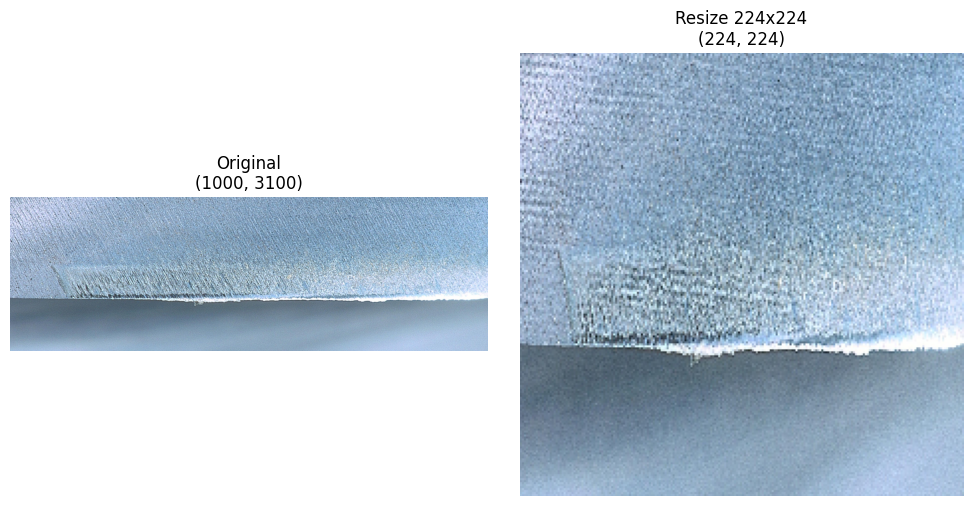

In [7]:
original = cv2.imread(str(sample_image))
original = cv2.cvtColor(original, cv2.COLOR_BGR2RGB)

resized = preprocess_image(sample_image)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(original)
plt.title(f"Original\n{original.shape[:2]}")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(resized)
plt.title(f"Resize 224x224\n{resized.shape[:2]}")
plt.axis("off")

plt.tight_layout()
plt.show()

<h5>Les images du jeu de données présentent des dimensions différentes, ce qui n'est pas compatible avec les modèles de Deep Learning. Afin d'obtenir une entrée homogène, toutes les images ont été redimensionnées à une résolution de 224 × 224 pixels à l'aide de la fonction cv2.resize() de la bibliothèque OpenCV. Cette étape permet de standardiser les données tout en réduisant le coût de calcul lors de l'entraînement du modèle.</h5>

<h3>Normalisation</h3>

In [8]:
normalized_image = resized.astype(np.float32) / 255.0

In [9]:
#test
print("Type :", normalized_image.dtype)
print("Valeur minimale :", normalized_image.min())
print("Valeur maximale :", normalized_image.max())

Type : float32
Valeur minimale : 0.03529412
Valeur maximale : 1.0


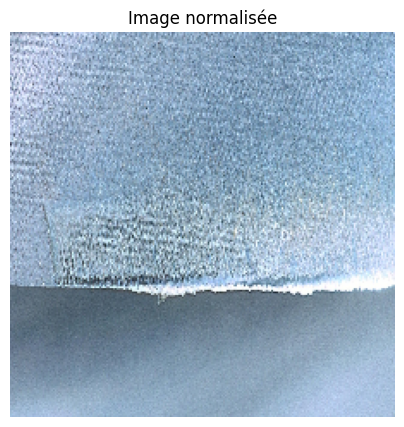

In [10]:
#Affichage
plt.figure(figsize=(5,5))
plt.imshow(normalized_image)
plt.title("Image normalisée")
plt.axis("off")
plt.show()

<h5>Après le redimensionnement, les images ont été normalisées en divisant les valeurs des pixels par 255. Cette opération transforme les valeurs initiales comprises entre 0 et 255 en valeurs comprises entre 0 et 1. La normalisation permet d'améliorer la stabilité de l'entraînement et d'accélérer la convergence du modèle de Deep Learning. </h5>

<h3>Création de l'encodeur</h3>

In [11]:
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()

label_encoder.fit(train_df["image_label"])

LabelEncoder()

In [12]:
#Encodage
train_labels = label_encoder.transform(train_df["image_label"])
val_labels = label_encoder.transform(val_df["image_label"])
test_labels = label_encoder.transform(test_df["image_label"])

In [13]:
#Test
print(label_encoder.classes_)

['dulled' 'sharp' 'used']


In [14]:
for i, label in enumerate(label_encoder.classes_):
    print(f"{label} --> {i}")

dulled --> 0
sharp --> 1
used --> 2


<h5>Les étiquettes textuelles des trois classes (Sharp, Used et Dulled) ont été converties en valeurs numériques à l'aide de la classe LabelEncoder de la bibliothèque Scikit-learn. Cette transformation est nécessaire, car les modèles de Deep Learning manipulent des valeurs numériques plutôt que des chaînes de caractères.</h5>

<h5>Ce chapitre a permis d'analyser et de préparer le jeu de données utilisé pour l'entraînement du modèle de Deep Learning. Une analyse exploratoire a été réalisée afin d'étudier la répartition des classes, les dimensions des images ainsi que leur qualité. Les opérations de prétraitement, notamment le redimensionnement des images, la normalisation des pixels et l'encodage des étiquettes, ont ensuite été appliquées. À l'issue de cette étape, les données sont prêtes à être utilisées pour l'entraînement et l'évaluation du modèle de classification présenté dans le chapitre suivant.</h5>

In [15]:
from sklearn.model_selection import train_test_split

# 1. Regrouper toutes les données
all_df = pd.concat([train_df, val_df, test_df], ignore_index=True)
print("Total :", len(all_df))
print(all_df["image_label"].value_counts())

# 2. Séparer test (15%) en premier - stratifié pour garder l'équilibre des classes
train_val_df, test_df_new = train_test_split(
    all_df,
    test_size=0.15,
    random_state=42,
    stratify=all_df["image_label"]
)

# 3. Séparer validation (15% du total) depuis le reste
train_df_new, val_df_new = train_test_split(
    train_val_df,
    test_size=0.176,   # 0.176 * 0.85 ≈ 0.15 du total
    random_state=42,
    stratify=train_val_df["image_label"]
)

# 4. Vérification
print("\nNouveau split :")
print(f"Train      : {len(train_df_new)} images")
print(f"Validation : {len(val_df_new)} images")
print(f"Test       : {len(test_df_new)} images")
print(f"Total      : {len(train_df_new) + len(val_df_new) + len(test_df_new)}")

print("\nDistribution validation :")
print(val_df_new["image_label"].value_counts())

# 5. Sauvegarder les nouveaux CSV (remplace les anciens)
train_df_new.to_csv(CSV_FOLDER / "train.csv", index=False)
val_df_new.to_csv(CSV_FOLDER / "val.csv", index=False)
test_df_new.to_csv(CSV_FOLDER / "test.csv", index=False)

print("\nNouveau CSV sauvegardés !")

Total : 2532
image_label
sharp     932
dulled    820
used      780
Name: count, dtype: int64

Nouveau split :
Train      : 1773 images
Validation : 379 images
Test       : 380 images
Total      : 2532

Distribution validation :
image_label
sharp     139
dulled    123
used      117
Name: count, dtype: int64

Nouveau CSV sauvegardés !
